In [38]:
from graph_transformer_long_range_niches.tl.wandb import load_and_log
from graph_transformer_long_range_niches.tl.load_config import Config
from graph_transformer_long_range_niches._paths import CFG_FILES, HE22_HUMAN_LUNG_DATA_PATH
from graph_transformer_long_range_niches.model.gnn_transformer import LitGNNTransformer
from graph_transformer_long_range_niches.tl.utils import pad_batch
from graph_transformer_long_range_niches.pl.color_map import CustomColormap
from graph_transformer_long_range_niches.tl.evaluation import eval_gnntransformer, extract_attention

import warnings
warnings.filterwarnings("ignore")
from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import scanpy as sc
import squidpy as sq

## Utility functions

In [2]:
def read(data_dir, split):
    """ Read PyG data from artifact folder
    """
    filename = split + ".pt"
    pyg_data = torch.load(os.path.join(data_dir, filename))
    return pyg_data # list with PyG Data objects

## Set global parameters

In [6]:
artifact_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts'
data_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts/he23_niche_sliding_window'

# Load data and model checkpoint

## Artifact from WandB

In [ ]:
cfg_path = Path(CFG_FILES, 'He23/he23_gnntrans_niche.yaml')
cfg = Config(cfg_path)

Download data

In [7]:
# data_name = f"{cfg.get('dataset/name')}_{cfg.get('dataset/prediction_obs')}_{cfg.get('dataset/library_key')}"
# run_name = f"download_{data_name}_{cfg.get('model/model_type')}"

# with wandb.init(project=cfg.get('wandb/project_name'), job_type="load-data", name = run_name) as run:
#     name = cfg.get('dataset/name')
#     data_artifact = run.use_artifact(f'{data_name}:latest')
#     #model_artifact = run.use_artifact(f'{run_name}_model:latest') #
#     #model_artifact = run.use_artifact('model-lfp748le:latest')

In [18]:
data = data_artifact.download()
#model = model_artifact.download()

wandb: Downloading large artifact he23_niche_sliding_window:latest, 6962.83MB. 3 files... 
wandb:   3 of 3 files downloaded.  
Done. 0:0:8.7


In [9]:
data_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts/he23_niche_sliding_window:v1' #TODO: adjust to downloaded dataset
pyg_data_val = read(data_dir, 'validation')

In [17]:
pyg_data_val[:3]

[Data(x=[2569, 960], edge_index=[2, 2274], y=[2569, 9], obs_names=[2569]),
 Data(x=[2612, 960], edge_index=[2, 2724], y=[2612, 9], obs_names=[2612]),
 Data(x=[2210, 960], edge_index=[2, 1404], y=[2210, 9], obs_names=[2210])]

In [18]:
model_path = f'{artifact_dir}/{run_name}_model:v1/{run_name}.ckpt'
checkpoint = torch.load(model_path)
cfg = checkpoint['hyper_parameters']['cfg']
model = LitGNNTransformer(cfg)

/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


## Download local objects

In [3]:
cfg_path = Path(CFG_FILES, 'He23/he23_gnntrans_niche.yaml')
cfg = Config(cfg_path)

Load cfg file...
{'out_dir': 'results', 'wandb': {'use': True, 'project_name': 'GTLongRange', 'run_idx': None}, 'model': {'model_type': 'gnn-transformer', 'n_epochs': 100}, 'optim': {'lr': 0.001, 'wd': '1e-3', 'warm_up': 10, 'seed': 42, 'loss': 'CrossEntropy'}, 'dataset': {'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad', 'name': 'he23', 'description': "CosmX Lung data from He23 with graphs for each .obs['sliding_window'] and prediction node .obs['niche'].", 'prediction_task': 'node', 'prediction_obs': 'niche', 'library_key': 'sliding_window', 'subset_dict': {}, 'spatial_neigbors_kwargs': {'radius': 50, 'coord_type': 'generic'}, 'batch_size': 20, 'train_size': 0.8, 'val_size': 0.2, 'test_size': 0.0}, 'gnn': {'gnn_type': 'GCN', 'num_layers': 2, 'hidden_dim': 256, 'embed_dim': 256, 'dropout': 0.1}, 'transformer': {'d_model': 128, 'n_heads': 4, 'dim_feedforward': 512, 'dropout': 0.3, 'num_layers': 4, 'acti

In [4]:
data_name = f"{cfg.get('dataset/name')}_{cfg.get('dataset/prediction_obs')}_{cfg.get('dataset/library_key')}"
run_name = f"download_{data_name}_{cfg.get('model/model_type')}"

In [7]:
model_path = f'{artifact_dir}/{data_name}_{cfg.get("model/model_type")}_model/model.ckpt'
checkpoint = torch.load(model_path)
cfg = checkpoint['hyper_parameters']['cfg']
model = LitGNNTransformer(cfg)

/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [8]:
model.load_state_dict(checkpoint['state_dict'])
# pyg_data_val = read(data_dir, 'validation')
# pyg_data_val[:3]

<All keys matched successfully>

# Attention matrix

`.self_attn` get [PyTorch MultiheadAttention](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html)

- attention is averaged across heads of one layer
- forward():
    - Out: 
        - `attn_output`: unbatched: (L, E) or batched: (L, B, E) with L = target sequence length, B = batch size, E = embedding dimension
          - The transformed input data after applying multi-head attention, useful for the next layers in the model.
        - `attn_output_weights`: attention weights averaged across heads of shape (L,S)(L,S) when input is unbatched or (N,L,S)(N,L,S), where NN is the batch size, L is the target sequence length, and S is the source sequence length.
          -  The weights showing how much each input element contributes to the output, useful for interpretability and understanding the attention mechanism.

In [11]:
from graph_transformer_long_range_niches.pp.geome_utils import prepare_geome_dataset
from graph_transformer_long_range_niches.tl.load_config import Config

cfg_path = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/He23/he23_gnntrans_niche.yaml'
cfg = Config(cfg_path)
pyg_datas, adata = prepare_geome_dataset(cfg)

Load cfg file...
{'out_dir': 'results', 'wandb': {'use': True, 'project_name': 'GTLongRange', 'run_idx': None}, 'model': {'model_type': 'gnn-transformer', 'n_epochs': 100}, 'optim': {'lr': 0.001, 'wd': '1e-3', 'warm_up': 10, 'seed': 42, 'loss': 'CrossEntropy'}, 'dataset': {'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad', 'name': 'he23', 'description': "CosmX Lung data from He23 with graphs for each .obs['sliding_window'] and prediction node .obs['niche'].", 'prediction_task': 'node', 'prediction_obs': 'niche', 'library_key': 'sliding_window', 'subset_dict': {}, 'spatial_neigbors_kwargs': {'radius': 50, 'coord_type': 'generic'}, 'batch_size': 20, 'train_size': 0.8, 'val_size': 0.2, 'test_size': 0.0}, 'gnn': {'gnn_type': 'GCN', 'num_layers': 2, 'hidden_dim': 256, 'embed_dim': 256, 'dropout': 0.1}, 'transformer': {'d_model': 128, 'n_heads': 4, 'dim_feedforward': 512, 'dropout': 0.3, 'num_layers': 4, 'acti

/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


call new


/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


{'niche': ['immune', 'lymphoid structure', 'macrophages', 'myeloid-enriched stroma', 'neutrophils', 'plasmablast-enriched stroma', 'stroma', 'tumor interior', 'tumor-stroma boundary']}
[Data(x=[1932, 960], edge_index=[2, 1584], y=[1932, 9], obs_names=[1932]), Data(x=[4250, 960], edge_index=[2, 6540], y=[4250, 9], obs_names=[4250]), Data(x=[3427, 960], edge_index=[2, 4182], y=[3427, 9], obs_names=[3427])]
333


### Evaluation on one slice

In [12]:
# subset data on FOV
library_key = 0
sub_adata = adata[adata.obs['library_key'] == library_key]
sub_adata

View of AnnData object with n_obs × n_vars = 98000 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'donor_id', 'author_cell_type', 'library_key', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', '_scvi_batch', '_scvi_labels', 'window', 'sliding_window'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'adj_matrix_neighbors', 'log1p', 'neighbors', 'niche', 'niche_colors', 'schema_version', 'title', 'umap', 'niche_mappings'
    obsm: 'X_pca', 'X_scvi', 'spatial', 'niche'
    layers: 'log1p', 'raw'

In [13]:
adata.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '771193', '771194', '771195', '771196', '771197', '771198', '771199',
       '771200', '771201', '771202'],
      dtype='object', length=771203)

In [14]:
pyg_nr = 0
pyg_datas[pyg_nr]

Data(x=[1932, 960], edge_index=[2, 1584], y=[1932, 9], obs_names=[1932])

In [15]:
# subset adata given cell names from pyg object
sub_obs_names = pyg_datas[pyg_nr].obs_names.numpy().astype(int).astype(str).tolist()
sub_adata = adata[adata.obs_names.isin(sub_obs_names)]

In [35]:
sub_adata

View of AnnData object with n_obs × n_vars = 1932 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'donor_id', 'author_cell_type', 'library_key', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', '_scvi_batch', '_scvi_labels', 'window', 'sliding_window'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'adj_matrix_neighbors', 'log1p', 'neighbors', 'niche', 'niche_colors', 'schema_version', 'title', 'umap', 'niche_mappings'
    obsm: 'X_pca', 'X_scvi', 'spatial', 'niche'
    layers: 'log1p', 'raw'

In [24]:
def eval_model(self, batched_data):
    h_node, z = self.gnn(batched_data.x, batched_data.edge_index)
    h_node = self.gnn2transformer(h_node) 
    padded_h_node, src_padding_mask, index_nodes, num_nodes, mask, max_num_nodes = pad_batch(
            h_node, batched_data.batch, self.transformer_encoder.max_input_len, get_mask=True
        )
    transformer_out, src_padding_mask = self.transformer_encoder(padded_h_node, src_padding_mask)
    return padded_h_node, transformer_out, src_padding_mask, index_nodes

In [37]:
def extract_attention(self, x, src_padding_mask):
    """Returns a list of attention maps (Tensor) for each Transformer layer.
    """
    attn_weights_maps = []
    attn_maps = []
        
    num_layers = self.transformer_encoder.num_layers
    num_heads = self.transformer_encoder.layers[0].self_attn.num_heads
    norm_first = self.transformer_encoder.layers[0].norm_first

    with torch.no_grad():
        for i in range(num_layers):
            # compute attention of layer i
            h = x.clone()
            if norm_first:
                h = self.transformer_encoder.layers[i].norm1(h)
            attn_output, attn_output_weights = self.transformer_encoder.layers[i].self_attn(h, h, h, need_weights=True, key_padding_mask=src_padding_mask)
            attn_maps.append(attn_output)
            attn_weights_maps.append(attn_output_weights)
            # forward of layer i
            x = self.transformer_encoder.layers[i](x)
            
        # attention_maps = torch.stack(attention_maps, dim=0)
        # attention_maps = torch.mean(attention_maps, dim=0)
        
    return attn_maps, attn_weights_maps

In [44]:
eval_loader = DataLoader(pyg_datas[:1], 1)

In [45]:
for batch in eval_loader:
    print(batch)
    transformer_in, transformer_out, src_padding_mask, index_nodes = eval(model, batch)
    print(f'transformer in: {transformer_in.shape}, out: {transformer_out.shape}')
    attn_maps, attn_weights_maps = extract_attention(model.transformer_encoder, transformer_out, src_padding_mask)

DataBatch(x=[1932, 960], edge_index=[2, 1584], y=[1932, 9], obs_names=[1932], batch=[1932], ptr=[2])
transformer in: torch.Size([1000, 1, 128]), out: torch.Size([1001, 1, 128])


In [46]:
for att_map, attn_weights in zip(attn_maps, attn_weights_maps):
    print(att_map.shape, attn_weights.shape)

torch.Size([1001, 1, 128]) torch.Size([1, 1001, 1001])
torch.Size([1001, 1, 128]) torch.Size([1, 1001, 1001])
torch.Size([1001, 1, 128]) torch.Size([1, 1001, 1001])
torch.Size([1001, 1, 128]) torch.Size([1, 1001, 1001])


## Cell level evaluation

In [12]:
cm = CustomColormap(np.insert(np.unique(adata.obs['niche']), 0, 'None'), none_color='#D3D3D3', cmap_name='he23_niche_custom')

In [260]:
cm.get_category_colors()

{'None': '#D3D3D3',
 'immune': '#ff7f0e',
 'lymphoid structure': '#2ca02c',
 'macrophages': '#d62728',
 'myeloid-enriched stroma': '#9467bd',
 'neutrophils': '#8c564b',
 'plasmablast-enriched stroma': '#e377c2',
 'stroma': '#7f7f7f',
 'tumor interior': '#bcbd22',
 'tumor-stroma boundary': '#17becf'}

In [262]:
adata

AnnData object with n_obs × n_vars = 771203 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'donor_id', 'author_cell_type', 'library_key', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', '_scvi_batch', '_scvi_labels', 'window', 'sliding_window'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'adj_matrix_neighbors', 'log1p', 'neighbors', 'niche', 'schema_version', 'title', 'umap', 'niche_mappings'
    obsm: 'X_pca', 'X_scvi', 'spatial', 'niche'
    layers: 'log1p', 'raw'

### Transformer input vs output

Compare the input to the transformer (GNN representation, capturing local patterns) with the transformer output (capturing global patterns)

Q: Can we find cells that benefit more from global attention than others? 

In [25]:
eval_loader = DataLoader(pyg_datas[:1], 1)
for batch in eval_loader:
    transformer_in, transformer_out, src_padding_mask, index_nodes = eval_model(model, batch)

In [29]:
assert transformer_in.shape == transformer_out[1:].shape

In [44]:
obs_names = pyg_datas[0].obs_names
obs_names.shape

torch.Size([1932])

In [58]:
# Prepare dataframe with values and niches or cell types
def make_dataframe(data, obs_names, index_nodes, adata, label):
    sub_obs_names = obs_names[index_nodes[0]]
    str_list = [str(i.astype(int)) for i in sub_obs_names.numpy()]
    sub_adata = adata[adata.obs_names.isin(str_list)].copy()
    df = pd.DataFrame(data, index=cm.get_category_colors()[sub_adata.obs[label]])
    return df

df = make_dataframe(diff, pyg_datas[0].obs_names, index_nodes, adata, 'niche')

In [59]:
df

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
niche,,,,,,,,,,,,,,,,,,,,,
stroma,-0.232642,-0.061705,-0.057769,0.105512,-0.343232,0.810381,0.096179,0.122854,-0.077110,0.770171,...,0.089333,-0.038456,-0.075362,0.625096,-0.477833,-0.256199,0.265080,-0.066263,-0.101493,0.455437
plasmablast-enriched stroma,-0.147294,0.066480,0.435312,0.141302,0.677953,-0.194052,0.124968,0.134017,-0.059366,0.470035,...,0.112835,-0.038945,0.009353,0.718736,0.556531,-0.174436,0.379495,0.059233,-0.024604,-0.014894
plasmablast-enriched stroma,-0.272707,0.074625,-0.854453,0.152517,-0.450714,0.624868,-0.177276,0.038533,-0.280257,0.770474,...,-0.249009,-0.049815,0.000118,0.112443,-0.702952,-0.272400,0.083401,-0.020894,0.095593,0.490572
plasmablast-enriched stroma,-0.169960,0.011622,0.227395,0.093480,-0.193288,0.097874,0.152669,0.150630,-0.060362,0.480390,...,0.132880,-0.045751,-0.082354,0.791814,0.210720,-0.239779,0.409537,-0.014893,-0.012961,0.430615
plasmablast-enriched stroma,0.132816,0.022827,0.209231,0.025633,0.244254,0.377257,0.056531,0.085549,-0.072244,1.734029,...,0.121214,-0.043698,-0.071373,1.187157,0.607987,-0.361173,-0.009899,0.004679,-0.144447,-0.027554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
lymphoid structure,-0.320699,-0.013912,0.054392,0.014535,-0.431416,1.175867,-0.008403,0.032410,-0.102902,1.124927,...,-0.027287,-0.045036,-0.145114,0.362077,-0.973269,-0.222927,-0.263586,-0.035239,-0.041817,-0.011585
stroma,-0.182825,0.135740,0.267626,0.138370,0.786933,-0.447267,0.228141,0.065229,-0.058046,0.202958,...,0.232819,-0.043095,0.029711,0.410542,0.371689,-0.236043,0.656869,-0.055921,0.074917,0.030791
plasmablast-enriched stroma,-0.220972,-0.045701,0.076308,0.086193,0.081432,0.746759,0.012783,0.061448,-0.082606,1.065240,...,0.026756,-0.039536,-0.147197,-0.222392,-0.418409,-0.157253,0.465100,0.064587,0.002679,-0.760824


In [64]:
# for each cell the cell type or niche
lut = dict(zip(df.index.unique(), "rbg"))
row_colors = df.index.map(lut)
row_colors

Index(['r', 'b', 'b', 'b', 'b', 'r', 'r', 'r', 'r', 'r',
       ...
       'r', 'r', 'r', 'r', 'r', 'g', 'r', 'b', 'r', 'r'],
      dtype='object', name='niche', length=1000)

In [35]:
diff = (transformer_in - transformer_out[1:]).view(1000,128).detach().numpy()

/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 800x600 with 0 Axes>

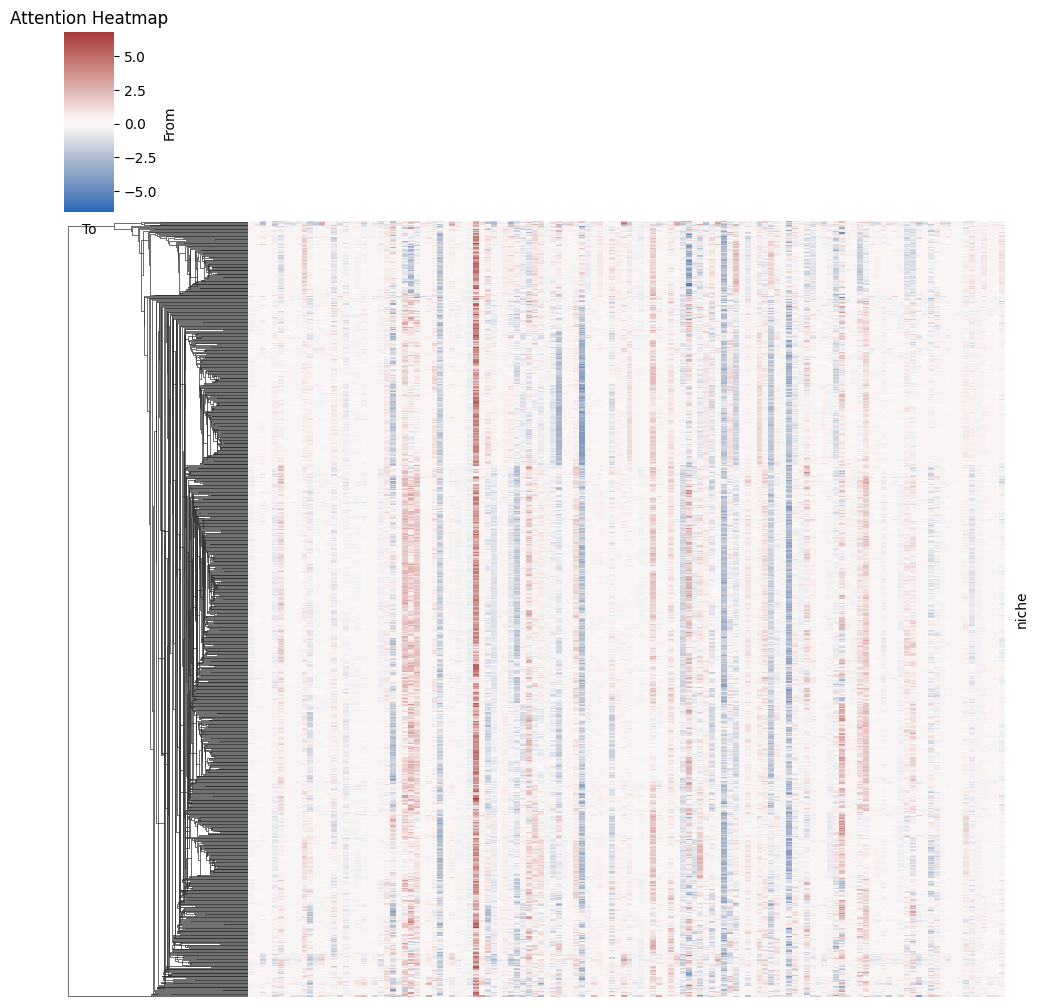

In [68]:
plt.figure(figsize=(8, 6))
clustergrid = sns.clustermap(df, annot=False, xticklabels=False, yticklabels=False, method="centroid", col_cluster=False, cmap="vlag")
plt.xlabel('To')
plt.ylabel('From')
plt.title('Attention Heatmap')
plt.show()

### Attention distribution

Which cells exhibit the same attention pattern?

In [289]:
batch_idx = 0
attn_output_batch = att_map[:, batch_idx, :]

In [290]:
attn_output_batch

tensor([[-0.1135, -0.0493, -0.1215,  ...,  0.0085, -0.0023, -0.1048],
        [-0.1131, -0.0501, -0.1251,  ...,  0.0064,  0.0023, -0.0871],
        [-0.1124, -0.0506, -0.1234,  ...,  0.0049,  0.0046, -0.0875],
        ...,
        [-0.1104, -0.0478, -0.1194,  ...,  0.0087, -0.0035, -0.1013],
        [-0.1139, -0.0493, -0.1225,  ...,  0.0092, -0.0018, -0.1006],
        [-0.1062, -0.0543, -0.1351,  ..., -0.0057,  0.0245, -0.0305]])

In [352]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

def get_cluster_labels(feature_matrix, num_clusters = 5):
    # Perform hierarchical clustering using a specific linkage method (e.g., 'ward')
    Z = linkage(feature_matrix, method='ward')
    # Form flat clusters by cutting the dendrogram at a specified number of clusters
    cluster_labels = fcluster(Z, num_clusters, criterion='maxclust')
    
    print("Cluster Labels:", len(cluster_labels))
    return cluster_labels

In [346]:
np.unique(cluster_labels, return_counts = True)

(array([1, 2, 3, 4, 5], dtype=int32), array([303, 111, 351,  94, 141]))

In [344]:
feature_matrix = transformer_out.view(1001, 128)[1:].detach().numpy()
feature_matrix.shape

(1000, 128)

DataBatch(x=[1932, 960], edge_index=[2, 1584], y=[1932, 9], obs_names=[1932], batch=[1932], ptr=[2])
Cluster Labels: 1000


/tmp/ipykernel_3919446/787721034.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sub_adata.obs['cluster_labels'].loc[sub_adata.obs_names.isin(sub_obs_names)] = cluster_labels.astype(str).tolist()
/tmp/ipykernel_3919446/787721034.py:12: 

0           3
1        None
5           5
6        None
7          10
         ... 
21272    None
21273       6
21275       9
21276       5
21277       8
Name: cluster_labels, Length: 1932, dtype: object


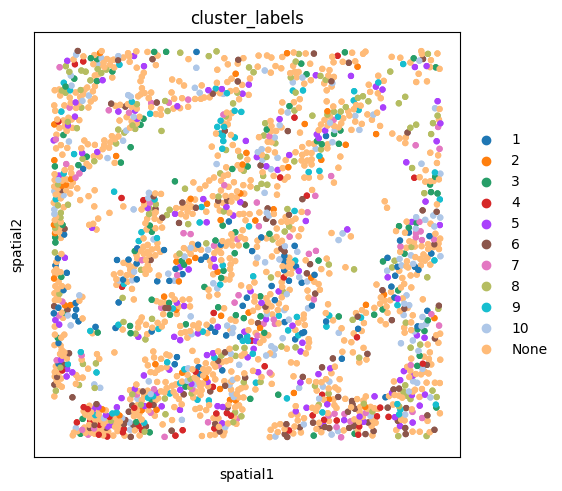

DataBatch(x=[1150, 960], edge_index=[2, 1016], y=[1150, 9], obs_names=[1150], batch=[1150], ptr=[2])
Cluster Labels: 1000


/tmp/ipykernel_3919446/787721034.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sub_adata.obs['cluster_labels'].loc[sub_adata.obs_names.isin(sub_obs_names)] = cluster_labels.astype(str).tolist()
/tmp/ipykernel_3919446/787721034.py:12: 

79194      10
79195       8
79196       7
79197    None
79198       7
         ... 
82286       4
82287       7
82288       7
82291       1
82292       2
Name: cluster_labels, Length: 1150, dtype: object


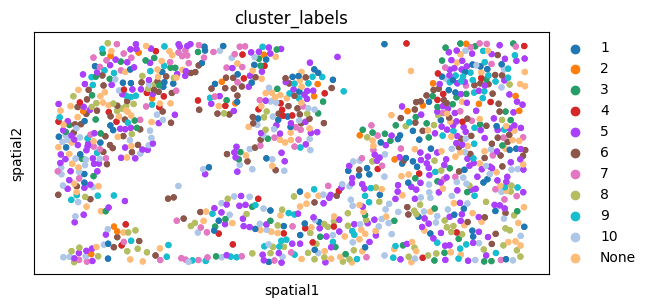

In [356]:
eval_loader = DataLoader([pyg_datas[0], pyg_datas[5]], 1)
for batch in eval_loader:
    print(batch)
    transformer_in, transformer_out, src_padding_mask, index_nodes = eval(model, batch)

    cluster_labels = get_cluster_labels(transformer_out.view(1001, 128)[1:].detach().numpy(), num_clusters = 10)

    batch_obs_names = batch.obs_names.numpy().astype(int).astype(str).tolist()
    sub_adata = adata[adata.obs_names.isin(batch_obs_names)].copy()
    sub_adata.obs['cluster_labels'] = 'None'
    sub_obs_names = sub_adata.obs_names[index_nodes[0]]
    sub_adata.obs['cluster_labels'].loc[sub_adata.obs_names.isin(sub_obs_names)] = cluster_labels.astype(str).tolist()
    print(sub_adata.obs['cluster_labels'])
    
    sq.pl.spatial_scatter(
        sub_adata,
        spatial_key = 'spatial',
        shape=None,
        library_key='library_key', 
        color=["cluster_labels"] ,
        #palette = cm.get_colormap_name(),
        size = 50,
    )
    plt.show()

/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 800x600 with 0 Axes>

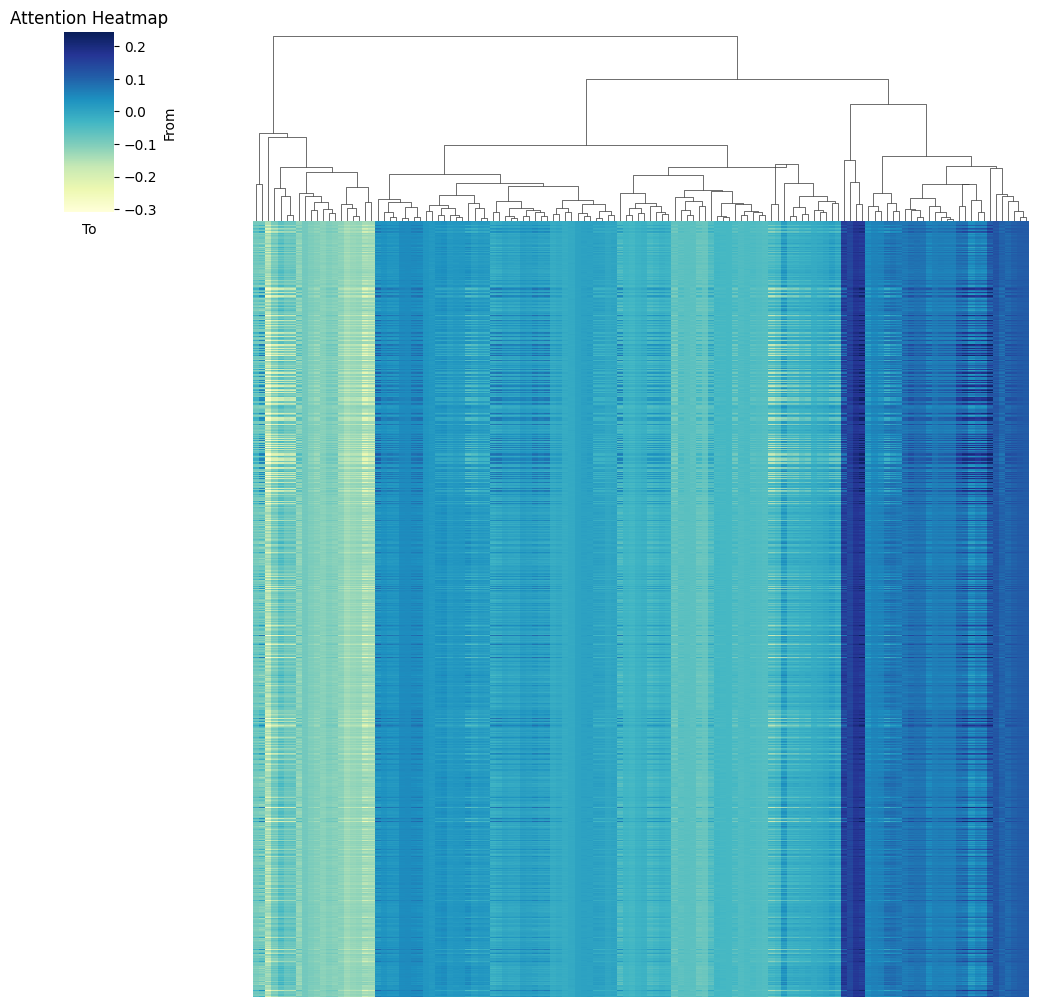

In [355]:
plt.figure(figsize=(8, 6))
clustergrid = sns.clustermap(attn_output_batch, annot=False, cmap='YlGnBu', xticklabels=False, yticklabels=False, method="centroid", row_cluster = False)
plt.xlabel('To')
plt.ylabel('From')
plt.title('Attention Heatmap')
plt.show()

In [300]:
len(row_cluster_labels)power

1001

In [305]:
np.unique(row_labels, return_counts=True)

(array([   0,    1,    2, ...,  998,  999, 1000]),
 array([1, 1, 1, ..., 1, 1, 1]))

### Spatial Tissue reconstruction

How well does the transformer predict the nodes in a tissue space?

How can we save the cell_IDs in the pyg objects such that we can relate them back to the adata object and the specific locations of the cells? -> add them to fields in geome

In [9]:
def node_level_prediction(self, transformer_out, src_padding_mask):
    h_graph = transformer_out[:-1] # [E, B, C]
    h_graph = torch.permute(h_graph, (1, 0, 2)) #[B, S, E]
    src_padding_mask = src_padding_mask[:,:-1] # True = Pad, False = Node
    masked_output = h_graph[~ src_padding_mask] # [N, E]
    out = self.graph_pred_linear(masked_output)
    return out

In [270]:
sub_adata.uns['niche_colors']

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

In [271]:
sub_adata.uns['pred_niche_colors']

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

In [21]:
adata.obs['donor_id']

0          Lung5
1          Lung5
2          Lung5
3          Lung5
4          Lung5
           ...  
771198    Lung13
771199    Lung13
771200    Lung13
771201    Lung13
771202    Lung13
Name: donor_id, Length: 771203, dtype: category
Categories (5, object): ['Lung5', 'Lung6', 'Lung9', 'Lung12', 'Lung13']

In [22]:
def spatial_tissue_reconstruction(dataloader, adata, model, label, library_key, cm, class_specific = False):
    """
    Input:
        cm - ColorMap
        library_key: str - 
    """
    for batch in dataloader:
        print(batch)
        transformer_in, transformer_out, src_padding_mask, index_nodes = eval_gnntransformer(model, batch)
        print(f'transformer in: {transformer_in.shape}, out: {transformer_out.shape}')
        out = node_level_prediction(model, transformer_out, src_padding_mask)
        # labels for cells
    
        batch_obs_names = batch.obs_names.numpy().astype(int).astype(str).tolist()
        sub_adata = adata[adata.obs_names.isin(batch_obs_names)].copy()
        sub_obs_names = sub_adata.obs_names[index_nodes[0]]
        label_mapping = sub_adata.uns[f'{label}_mappings']

        print(np.unique(sub_adata.obs['donor_id']))

        if class_specific:
            for i, class_label in enumerate(label_mapping[label]):
                sub_adata.obs[f'pred_{class_label}'] = 0
                sub_adata.obs[f'pred_{class_label}'].loc[sub_adata.obs_names.isin(sub_obs_names)] = out.detach().numpy()[:, i]
                #sub_adata.obs[f'pred_{c}'] = out.detach().numpy()[:, i]
                sq.pl.spatial_scatter(
                    sub_adata,
                    spatial_key = 'spatial',
                    shape=None,
                    library_key=library_key, 
                    color=[f"pred_{class_label}"] ,
                    #palette = cm.get_colormap_name(),
                    size = 50,
                )
                plt.show()


        else:
            y_pred = out.argmax(dim=1)
            print(out.shape)
            sub_adata.obs[f'pred_{label}'] = 'None'
            y_pred_label = [label_mapping[f'{label}'][i] for i in y_pred]
            sub_adata.obs[f'pred_{label}'].loc[sub_adata.obs_names.isin(sub_obs_names)] = y_pred_label
            
            for l in [f'{label}', f"pred_{label}"]:
                sub_adata = cm.save_uns(sub_adata, l)
                
            sq.pl.spatial_scatter(
                sub_adata,
                spatial_key = 'spatial',
                shape=None,
                library_key=library_key, 
                color=[f'{label}', f"pred_{label}"] ,
                #palette = cm.get_colormap_name(),
                size = 50,
            )
            plt.show()

DataBatch(x=[511, 960], edge_index=[2, 548], y=[511, 9], obs_names=[511], batch=[511], ptr=[2])
transformer in: torch.Size([511, 1, 128]), out: torch.Size([512, 1, 128])
['Lung9']
torch.Size([511, 9])


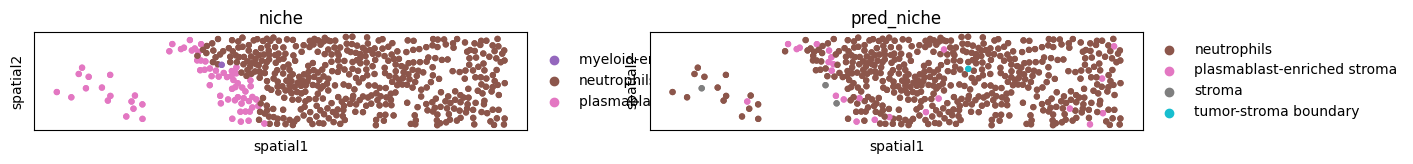

DataBatch(x=[511, 960], edge_index=[2, 548], y=[511, 9], obs_names=[511], batch=[511], ptr=[2])
transformer in: torch.Size([511, 1, 128]), out: torch.Size([512, 1, 128])
['Lung9']


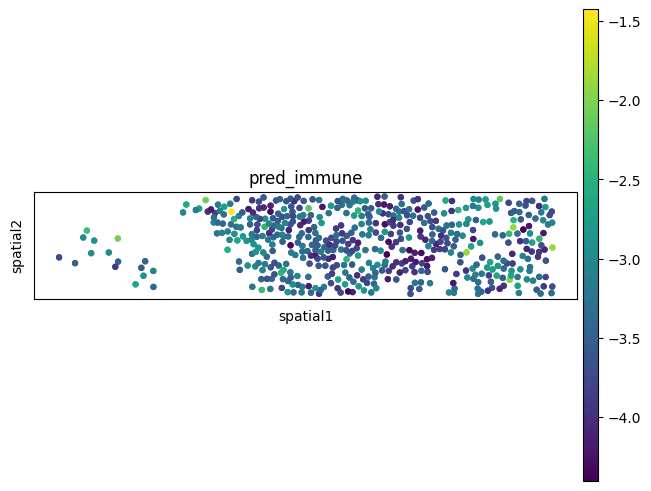

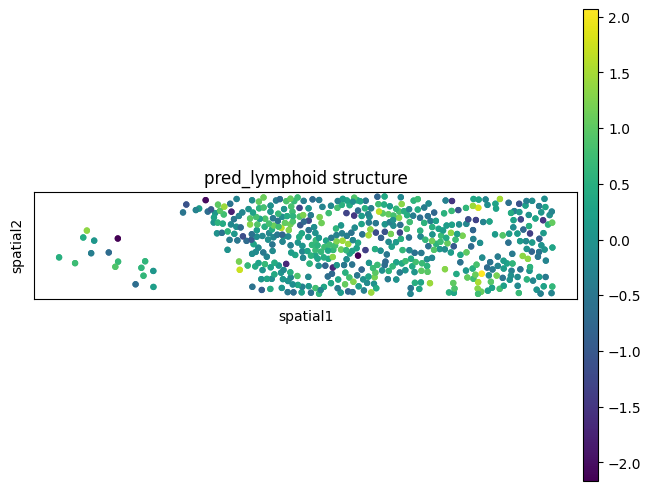

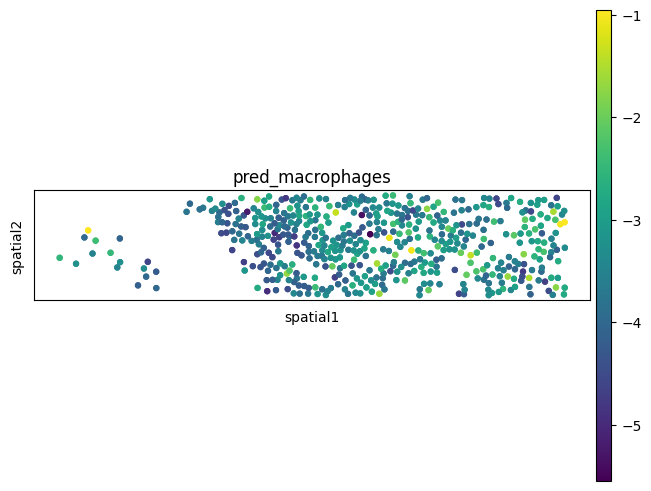

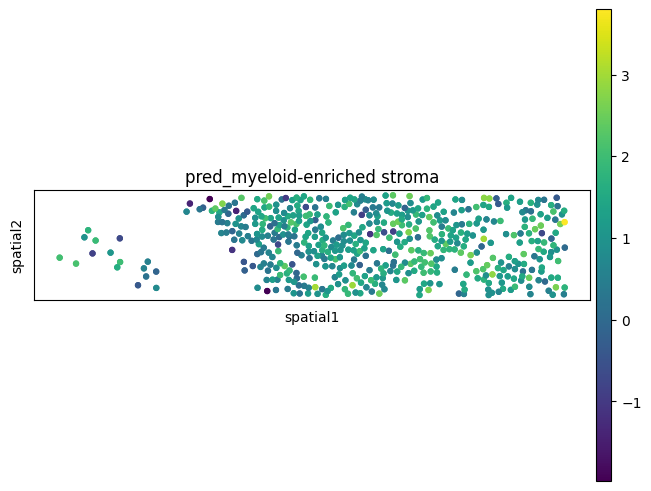

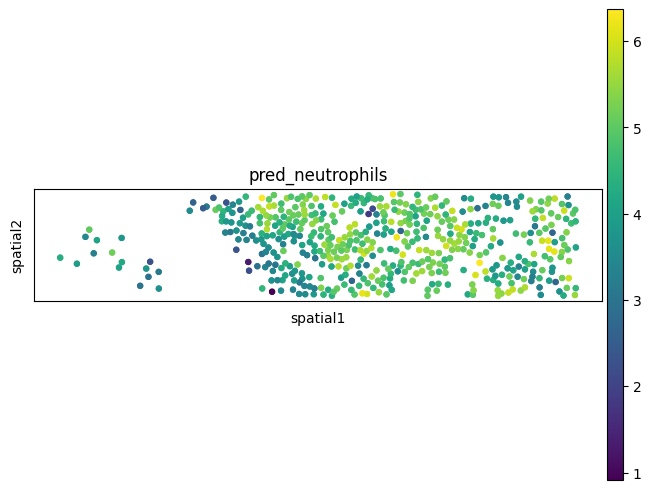

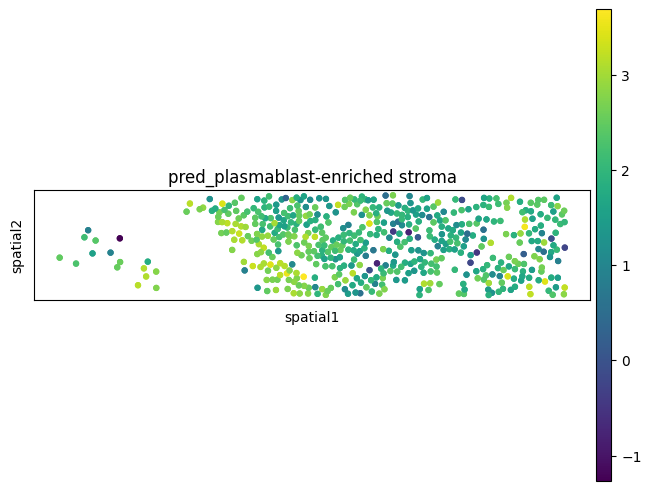

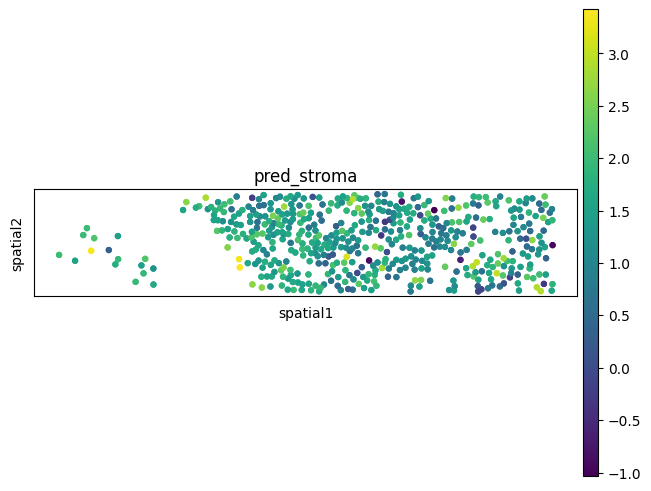

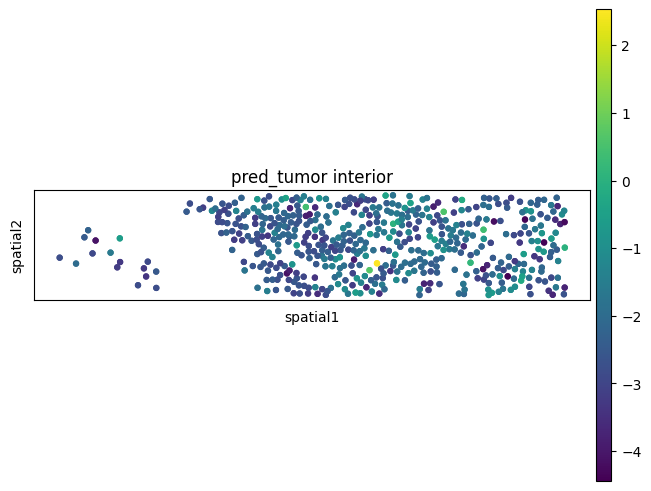

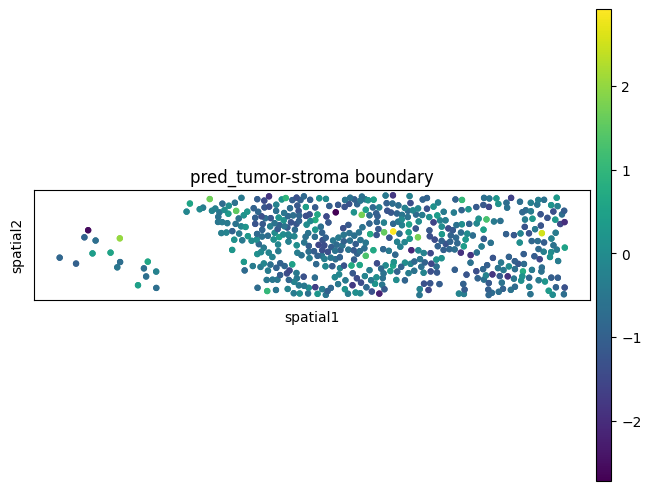

In [47]:
eval_loader = DataLoader([pyg_datas[206]], 1)
spatial_tissue_reconstruction(eval_loader, adata, model, 'niche', 'sliding_window', cm, class_specific = False)
spatial_tissue_reconstruction(eval_loader, adata, model, 'niche', 'sliding_window', cm, class_specific = True)

DataBatch(x=[1932, 960], edge_index=[2, 1584], y=[1932, 9], obs_names=[1932], batch=[1932], ptr=[2])
transformer in: torch.Size([1000, 1, 128]), out: torch.Size([1001, 1, 128])


/tmp/ipykernel_3919446/1995524683.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sub_adata.obs['pred_niche'].loc[sub_adata.obs_names.isin(sub_obs_names)] = y_pred_label
/tmp/ipykernel_3919446/1995524683.py:17: SettingWithCopyWarning: 


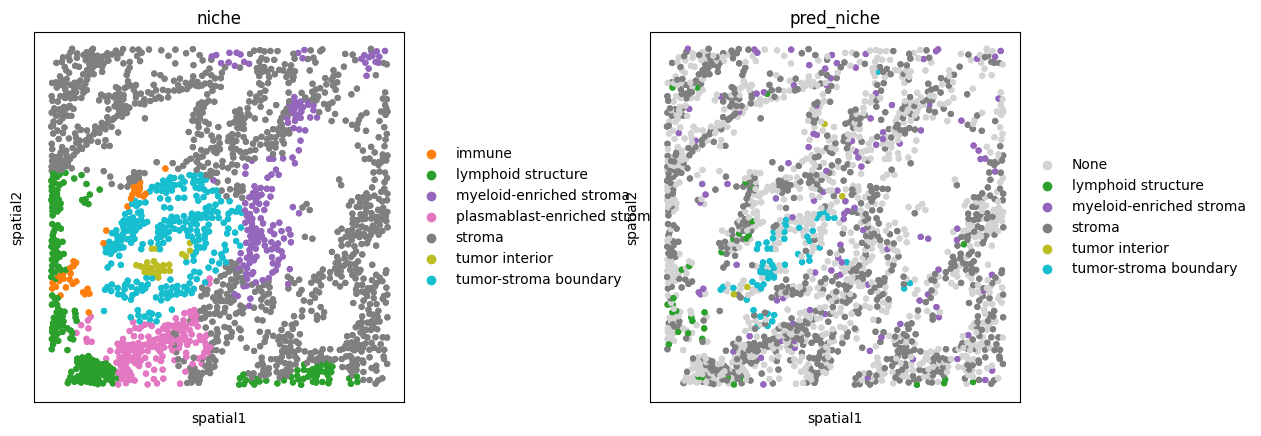

DataBatch(x=[1150, 960], edge_index=[2, 1016], y=[1150, 9], obs_names=[1150], batch=[1150], ptr=[2])
transformer in: torch.Size([1000, 1, 128]), out: torch.Size([1001, 1, 128])


/tmp/ipykernel_3919446/1995524683.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sub_adata.obs['pred_niche'].loc[sub_adata.obs_names.isin(sub_obs_names)] = y_pred_label
/tmp/ipykernel_3919446/1995524683.py:17: SettingWithCopyWarning: 


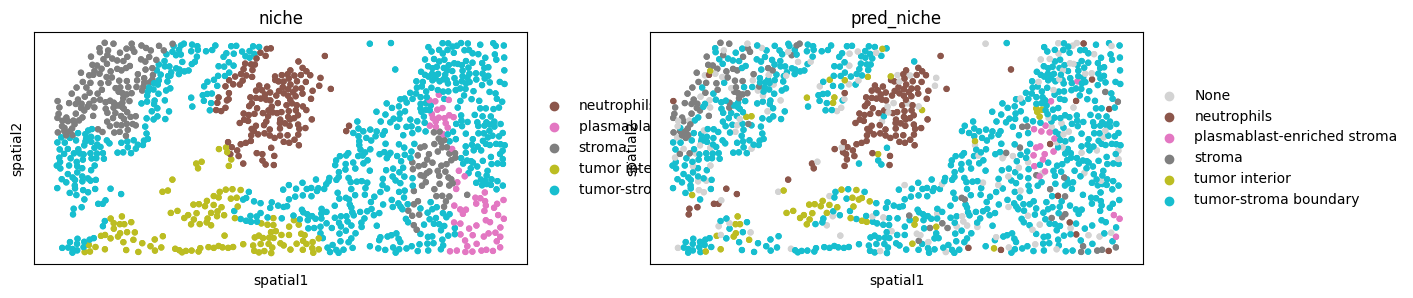

In [275]:
eval_loader = DataLoader([pyg_datas[0], pyg_datas[5]], 1)
for batch in eval_loader:
    print(batch)
    transformer_in, transformer_out, src_padding_mask, index_nodes = eval(model, batch)
    print(f'transformer in: {transformer_in.shape}, out: {transformer_out.shape}')
    out = node_level_prediction(model, transformer_out, src_padding_mask)
    # labels for cells

    batch_obs_names = batch.obs_names.numpy().astype(int).astype(str).tolist()
    sub_adata = adata[adata.obs_names.isin(batch_obs_names)].copy()
    y_pred = out.argmax(dim=1)
    niche_mappings = sub_adata.uns['niche_mappings']
    sub_adata.obs['pred_niche'] = 'None'
    y_pred_label = [niche_mappings['niche'][i] for i in y_pred]
    sub_obs_names = sub_adata.obs_names[index_nodes[0]]
    sub_adata.obs['pred_niche'].loc[sub_adata.obs_names.isin(sub_obs_names)] = y_pred_label
    
    for label in ["niche", "pred_niche"]:
        sub_adata = cm.save_uns(sub_adata, label)

    sq.pl.spatial_scatter(
        sub_adata,
        spatial_key = 'spatial',
        shape=None,
        library_key='library_key', 
        color=["niche", "pred_niche"] ,
        #palette = cm.get_colormap_name(),
        size = 50,
    )
    plt.show()

## Visualization of Embeddings

### 1. Dimensionality reduction

Use techniques like PCA or t-SNE to reduce the dimensionality of the embeddings in attn_output and visualize them. This can help you see clusters or patterns in the transformed embeddings.

In [27]:
pyg_data_val[2].y.shape

torch.Size([457, 9])

In [ ]:
import pandas as pd

pyg_data_val[2].y

torch.Size([457, 128])


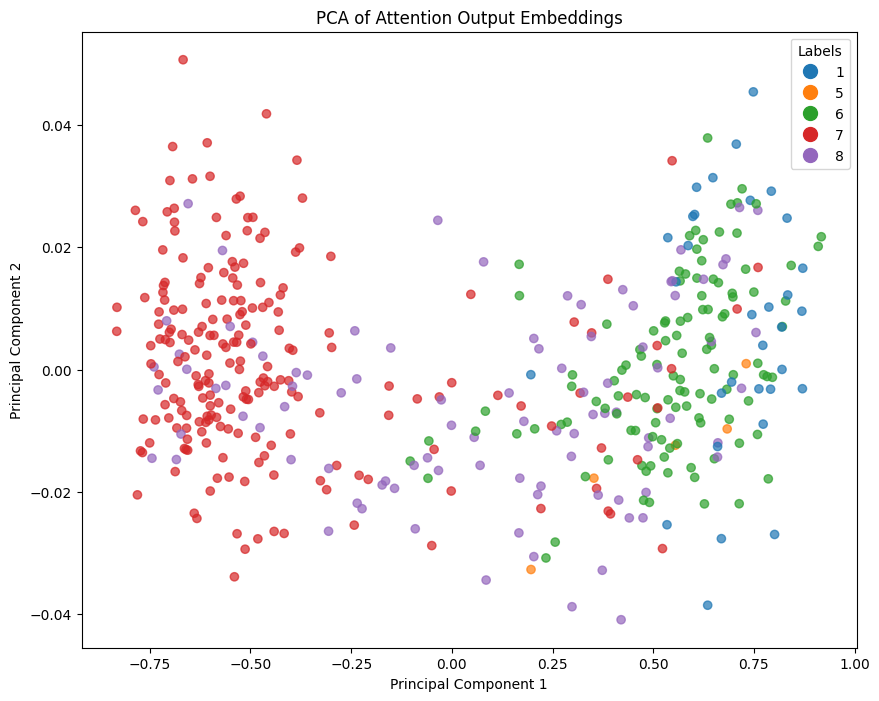

In [33]:
from sklearn.decomposition import PCA
import numpy as np

batch_idx = 0
attn_output_batch = att_map[:, batch_idx, :]  # Shape: (sequence length, embedding dimension)
print(attn_output_batch.shape)

# Print some embeddings
# print("Embeddings for the first few elements in the sequence:")
# print(attn_output_batch[:5, :])  # Print embeddings for the first 5 elements

# Use PCA to reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
attn_output_reduced = pca.fit_transform(attn_output_batch.detach().numpy())
labels = np.argmax(pyg_data_val[2].y, axis=1).numpy()
assert len(labels) == attn_output_reduced.shape[0], "Mismatch between labels and embeddings"

# Map each label to a color from the colormap
cmap = plt.get_cmap('tab10')
unique_labels = np.unique(labels)
color_map = {label: cmap(i) for i, label in enumerate(unique_labels)}

# Map labels to colors
point_colors = [color_map[label] for label in labels]

# Plot the reduced embeddings with colors according to their labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(attn_output_reduced[:, 0], attn_output_reduced[:, 1], c=point_colors, alpha=0.7)

# Create a legend
handles = [plt.Line2D([0], [0], marker='o', color=color_map[label], linestyle='', markersize=10) for label in unique_labels]
plt.legend(handles, unique_labels, title='Labels')

plt.title("PCA of Attention Output Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Idea: 
- color cells by cell type or niches# Select a batch for analysis (e.g., batch 0)
- apply Leiden clustering on cells, what kind of niches do we find?
- How far away are cells on average?

### Similarity between Embeddings

Compute the similarity (e.g., cosine similarity) between different embeddings in the attn_output to see which elements of the sequence are represented similarly after attention.

In [ ]:
import torch.nn.functional as F

# Select a batch for analysis (e.g., batch 0)
batch_idx = 0
attn_output_batch = att_map[:, batch_idx, :]  # Shape: (sequence length, embedding dimension)

# Compute Cosine Similarity
cosine_similarity_matrix = F.cosine_similarity(
    attn_output_batch.unsqueeze(1),  # Shape: (sequence length, 1, embedding dimension)
    attn_output_batch.unsqueeze(0),  # Shape: (1, sequence length, embedding dimension)
    dim=2
)  # Shape: (sequence length, sequence length)

# Print the Cosine Similarity Matrix
print("Cosine Similarity Matrix:")
print(cosine_similarity_matrix)

sequence_length = 457 # ToDo: adjust flexible

# Visualize the Cosine Similarity Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cosine_similarity_matrix.detach().numpy(), annot=True, cmap='viridis', xticklabels=range(sequence_length), yticklabels=range(sequence_length))
plt.title("Cosine Similarity Matrix of Attention Output Embeddings")
plt.xlabel("Sequence Element")
plt.ylabel("Sequence Element")
plt.show()